# Practical 3 — From Nonlinear Regression to Classification

**Guided dataset:** UCI Abalone  
**Independent challenge:** UCI QSAR Bioconcentration Classes

## Learning goals

By the end of this practical you should be able to:

1. inspect a biological tabular dataset before modelling;
2. formulate **regression** and **classification** questions from the same data;
3. build and evaluate baseline regression and classification models;
4. recognize when methods from the **Regression Zoo** are appropriate;
5. fit several nonlinear, robust, latent-variable, probabilistic, and symbolic regression models;
6. understand why **mixed-effects models require grouped/repeated observations**;
7. prepare predictions for a hidden-data challenge without leaking the hidden targets.

In [1]:

import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.linear_model import (
    HuberRegressor,
    LinearRegression,
    LogisticRegression,
    QuantileRegressor,
    Ridge,
)
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    PolynomialFeatures,
    SplineTransformer,
    StandardScaler,
)
from ucimlrepo import fetch_ucirepo

RANDOM_STATE = 230926

# Part I — Guided analysis: Abalone

The UCI Abalone dataset contains physical measurements of individual abalones. 
https://archive.ics.uci.edu/dataset/1/abalone
The original target is **Rings**. UCI notes that `Rings + 1.5` is an approximate age in years.
![Alternative Text](https://www.conxemar.com/wp-content/uploads/catalogo-especies/img/HLT-1024x712.webp)

We will deliberately formulate **two different machine-learning tasks from the same biological observations**:

### Task A — Regression
Predict the number of rings:


### Task B — Classification
Convert ring count into age categories and predict the category:


In [2]:
abalone = fetch_ucirepo(id=1)

X_raw = abalone.data.features.copy()
y_raw = abalone.data.targets.copy()

df = X_raw.copy()
df["Rings"] = y_raw.iloc[:, 0].to_numpy()

df.shape


(4177, 9)

# Universal biological data-preparation checklist


## Scientific purpose and provenance

- [ ] Is the biological question and prediction task stated clearly? To predict body mass from morph parameters
- [ ] Is the unit of observation clear (for example, patient, tissue, cell, mouse, or technical measurement)?
- [ ] Do I know where the data came from, how they were generated, and under which license or access conditions they may be used?
- [ ] Have I recorded the data version, processing history, and transformations already applied?

## Table shape and identifiers

- [ ] Is the table tidy: one observation per row, one variable per column, and one value per cell?
- [ ] If the original assay has features in rows and samples in columns, have I transposed it into the format expected by the analysis tool?
- [ ] Are row names, column names, and identifiers clear, unique, stable, and free from accidental index columns?
- [ ] Can every feature and observation be traced back to its source?
- [ ] Are the feature matrix and metadata aligned by an explicit identifier rather than by row order?

## Types, values, and measurement meaning

- [ ] Are numerical, categorical, ordinal, text, date, and identifier columns correctly classified?
- [ ] Are units, scales, encodings, reference categories, and detection limits understood?
- [ ] Have I checked impossible values, inconsistent labels, unexpected categories, constant features, and extreme values?
- [ ] Are normalization, scaling, log transformation, and batch-correction steps documented?

In [3]:
df.columns

Index(['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight',
       'Viscera_weight', 'Shell_weight', 'Rings'],
      dtype='object')

In [4]:
display(abalone.variables)

,name,role,type,demographic,description,units,missing_values
0,Sex,Feature,Categorical,None,"M, F, and I (infant)",None,no
1,Length,Feature,Continuous,None,Longest shell measurement,mm,no
2,Diameter,Feature,Continuous,None,perpendicular to length,mm,no
3,Height,Feature,Continuous,None,with meat in shell,mm,no
4,Whole_weight,Feature,Continuous,None,whole abalone,grams,no
5,Shucked_weight,Feature,Continuous,None,weight of meat,grams,no
6,Viscera_weight,Feature,Continuous,None,gut weight (after bleeding),grams,no
7,Shell_weight,Feature,Continuous,None,after being dried,grams,no
8,Rings,Target,Integer,None,+1.5 gives the age in years,None,no


In [5]:
df.columns.is_unique

True

- [ ] Have I detected missing values using the dataset's actual missing-value representations, not only `NaN`?
- [ ] Have I measured missingness by row, column, group, and relevant batch or time variable?
- [ ] Do I know whether missingness is structural, technical, or plausibly related to the biology or target?
- [ ] Have I justified whether to retain, remove, or impute missing values?
- [ ] If imputing, will the imputer be fitted on training data only and then applied to validation/test data?

## Replicates, dependence, and grouping

- [ ] Have I checked for exact duplicates and near-duplicate observations?
- [ ] Are observations biological replicates, technical replicates, repeated measurements, pseudo-replicates, or independent samples?
- [ ] Is the independent biological unit identified by a grouping variable?
- [ ] Will all related observations and their derivatives remain in the same train/validation/test split?
- [ ] If I created augmented or synthetic observations, is their provenance recorded and reproducible?


In [6]:
missing_by_column = df.isna().sum().sort_values(ascending=False)
missing_by_row = df.isna().sum(axis=1)

display(missing_by_column.to_frame("missing_count"))
display((missing_by_column / len(df)).to_frame("missing_fraction"))
print("Rows with at least one missing value:", int((missing_by_row > 0).sum()))
print("Rows with more than one missing value:", int((missing_by_row > 1).sum()))

,missing_count
Sex,0
Length,0
Diameter,0
Height,0
Whole_weight,0
Shucked_weight,0
Viscera_weight,0
Shell_weight,0
Rings,0


,missing_fraction
Sex,0.0
Length,0.0
Diameter,0.0
Height,0.0
Whole_weight,0.0
Shucked_weight,0.0
Viscera_weight,0.0
Shell_weight,0.0
Rings,0.0


Rows with at least one missing value: 0
Rows with more than one missing value: 0


In [7]:

print("Exact duplicate rows", int(df.duplicated().sum()))


Exact duplicate rows 0



## Target, leakage, and study design

- [ ] Is the target defined before modelling, with its classes or values checked for balance and validity?
- [ ] Have I excluded identifiers, post-outcome variables, duplicated target information, and other leakage sources from the features?
- [ ] Have I identified batch, site, plate, subject, cohort, treatment, sex, age, time, or other possible confounders?
- [ ] Have I checked whether the target is associated with a technical or grouping variable?
- [ ] Does the planned split represent the biological generalization question?

## 2. Define the two targets

For classification we create three age groups from ring count.

The cut-offs below are **pedagogical choices**, not biological ground truth. This is useful because it demonstrates an important point:

> A dataset does not determine the ML task by itself. The scientific question and target definition do.

After constructing `Age_class`, **Rings must not be included among classification predictors**, otherwise the answer leaks directly into the input.

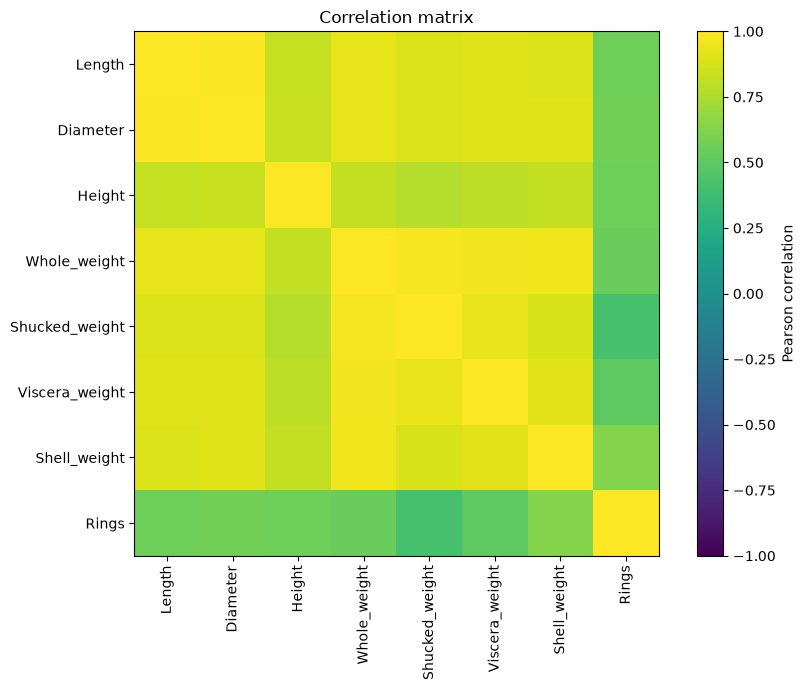

In [8]:
corr = df.drop(columns="Sex").corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=90)
ax.set_yticks(range(len(corr.columns)), corr.columns)
fig.colorbar(im, ax=ax, label="Pearson correlation")
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

In [9]:
#Class label
df["Age_class"] = pd.cut(
    df["Rings"],
    bins=[-np.inf, 8, 10, np.inf],
    labels=["young", "middle", "old"]
)

display(pd.crosstab(df["Age_class"], columns="count"))

col_0,count
Age_class,
young,1407
middle,1323
old,1447


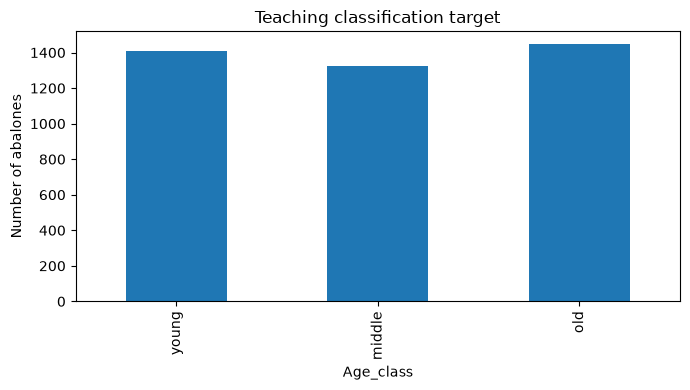

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
df["Age_class"].value_counts().reindex(["young", "middle", "old"]).plot.bar(ax=ax)
ax.set_ylabel("Number of abalones")
ax.set_title("Teaching classification target")
plt.tight_layout()
plt.show()

## EDA — distributions and measurement scales

Before modelling, inspect the marginal distribution of every numeric variable. Histograms can reveal skewness, outliers, bounded measurements, multimodality, and variables that may need transformation or robust modelling.

The `Rings` distribution is also important because it is used as the regression target and to construct the teaching classification target.

,count,mean,std,min,50%,max
Length,4177.0,0.523992,0.120093,0.0750,0.5450,0.8150
Diameter,4177.0,0.407881,0.099240,0.0550,0.4250,0.6500
Height,4177.0,0.139516,0.041827,0.0000,0.1400,1.1300
Whole_weight,4177.0,0.828742,0.490389,0.0020,0.7995,2.8255
Shucked_weight,4177.0,0.359367,0.221963,0.0010,0.3360,1.4880
Viscera_weight,4177.0,0.180594,0.109614,0.0005,0.1710,0.7600
Shell_weight,4177.0,0.238831,0.139203,0.0015,0.2340,1.0050
Rings,4177.0,9.933684,3.224169,1.0000,9.0000,29.0000


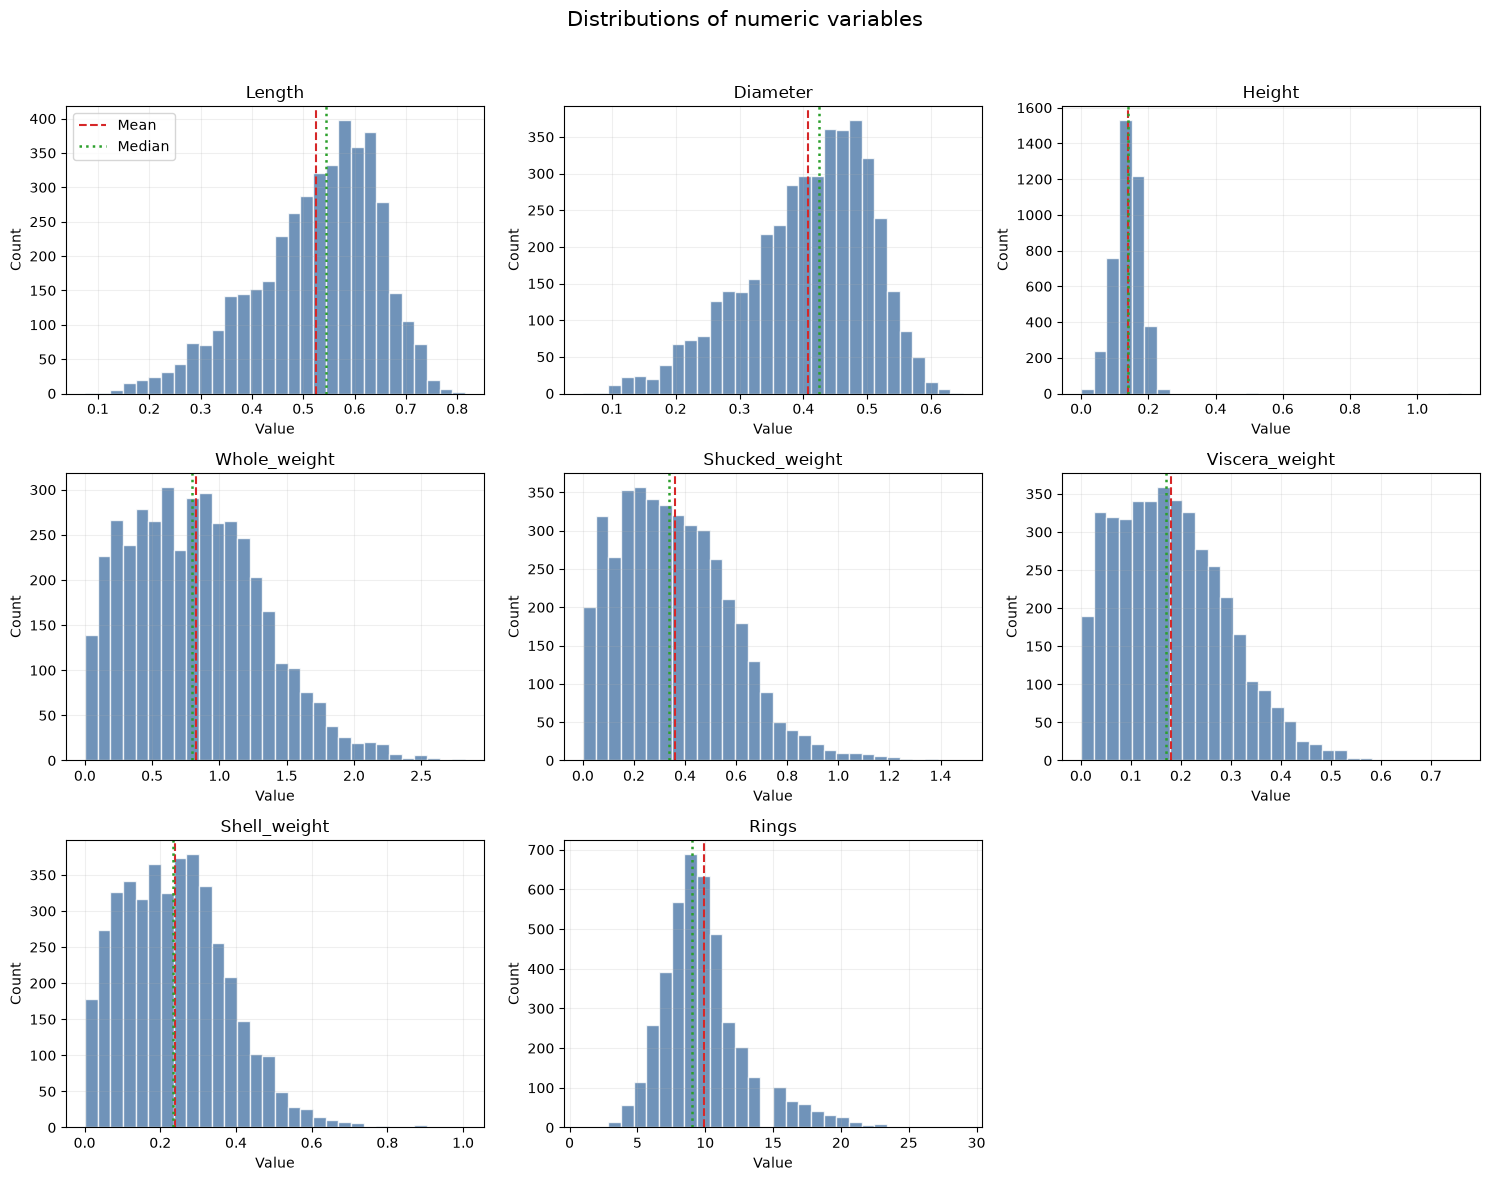

In [11]:
numeric_eda_cols = df.select_dtypes(include=np.number).columns.tolist()
display(df[numeric_eda_cols].describe().T[["count", "mean", "std", "min", "50%", "max"]])

n_cols = 3
n_rows = int(np.ceil(len(numeric_eda_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, column in zip(axes, numeric_eda_cols):
    values = df[column].dropna()
    ax.hist(values, bins=30, color="#4c78a8", alpha=0.8, edgecolor="white")
    ax.axvline(values.mean(), color="#d62728", linestyle="--", linewidth=1.5, label="Mean")
    ax.axvline(values.median(), color="#2ca02c", linestyle=":", linewidth=1.8, label="Median")
    ax.set_title(column)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.2)

for ax in axes[len(numeric_eda_cols):]:
    ax.set_visible(False)
axes[0].legend(frameon=True)
fig.suptitle("Distributions of numeric variables", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Rings
1       1
2       1
3      15
4      57
5     115
6     259
7     391
8     568
9     689
10    634
11    487
12    267
13    203
14    126
15    103
16     67
17     58
18     42
19     32
20     26
21     14
22      6
23      9
24      2
25      1
26      1
27      2
29      1
Name: count, dtype: int64

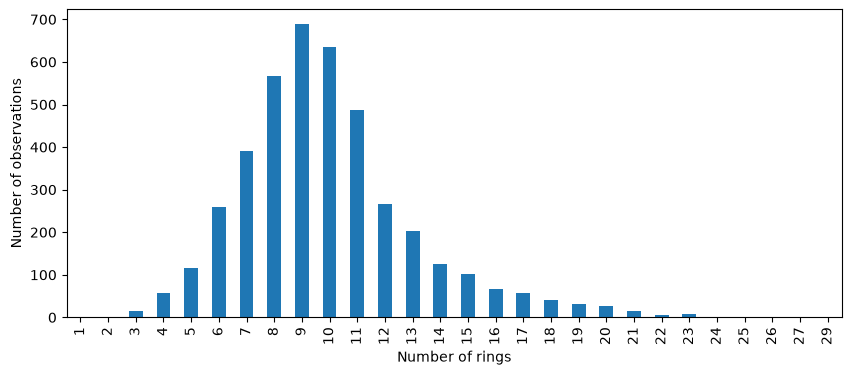

In [12]:
ring_counts = (
    df["Rings"]
    .value_counts()
    .sort_index())

display(ring_counts)

ring_counts.plot.bar(figsize=(10, 4))
plt.xlabel("Number of rings")
plt.ylabel("Number of observations")
plt.show()

# Part II — Regression

We first create one train/test split and reuse it for model comparison.

For regression:

- target: `Rings`
- categorical predictor: `Sex`
- numeric predictors: all physical measurements

The test set is kept separate from model fitting.

In [13]:
X = df.drop(columns=["Rings", "Age_class"])
y_reg = df["Rings"].astype(float)

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg,
    test_size=0.20,
    random_state=RANDOM_STATE)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop=None), cat_cols)])

def regression_metrics(name, y_true, y_pred):
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)}

regression_results = []

def plot_observed_vs_predicted(y_true, y_pred, title):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    low = min(y_true.min(), y_pred.min())
    high = max(y_true.max(), y_pred.max())
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(y_true, y_pred, alpha=0.55, color="#4c78a8")
    ax.plot([low, high], [low, high], color="#d62728", linestyle="--", linewidth=2, label="Perfect prediction")
    ax.set_xlabel("Observed Rings")
    ax.set_ylabel("Predicted Rings")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend(frameon=True)
    fig.tight_layout()
    plt.show()

## 3. Baseline: ordinary linear regression

The linear model represents the conditional mean as

$$
\hat{y}_i = \beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip} + \varepsilon_i.
$$

The fitted coefficients are chosen to minimize the sum of squared residuals.

,model,MAE,RMSE,R2
0,Linear regression,1.555982,2.115134,0.544654


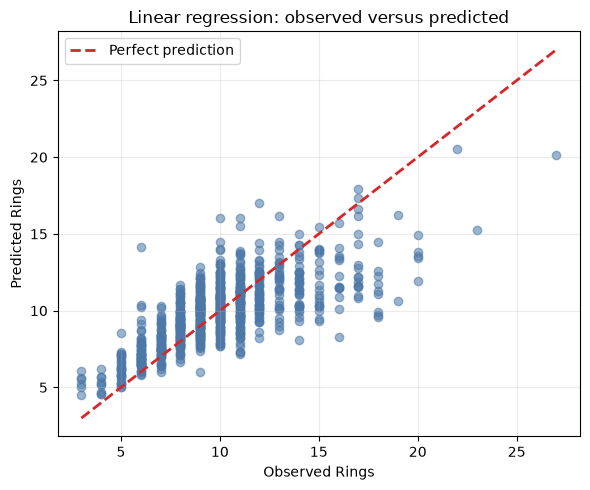

In [14]:
linear_model = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())])

linear_model.fit(X_train, y_train)
pred_linear = linear_model.predict(X_test)

regression_results.append(
    regression_metrics("Linear regression", y_test, pred_linear))

display(pd.DataFrame(regression_results))
plot_observed_vs_predicted(y_test, pred_linear, "Linear regression: observed versus predicted")

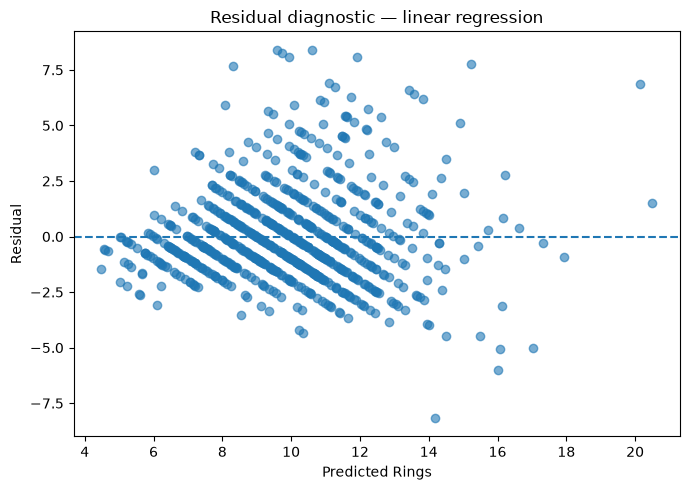

In [15]:
residuals = y_test.to_numpy() - pred_linear

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pred_linear, residuals, alpha=0.6)
ax.axhline(0, linestyle="--")
ax.set_xlabel("Predicted Rings")
ax.set_ylabel("Residual")
ax.set_title("Residual diagnostic — linear regression")
plt.tight_layout()
plt.show()

# 4. Regression Zoo

We now revisit methods from the lecture.



## 4.1 Polynomial regression

Polynomial regression keeps a linear estimator but expands the predictor representation with nonlinear terms.

For one predictor, a degree-2 model is

$$
\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2.
$$

`degree` controls the highest power included. With many predictors, high-degree expansion grows quickly, so we use degree 2.

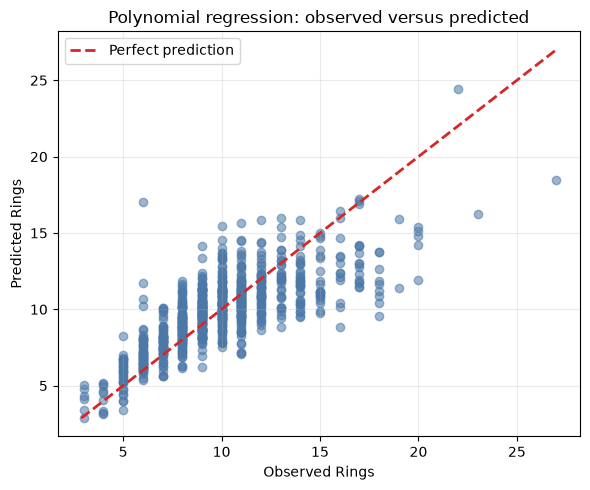

[{'model': 'Linear regression',
  'MAE': 1.5559821743470073,
  'RMSE': np.float64(2.1151338807031688),
  'R2': 0.5446537272148526},
 {'model': 'Polynomial (degree 2)',
  'MAE': 1.482316401766949,
  'RMSE': np.float64(2.046146965924892),
  'R2': 0.5738723547716844}]

In [16]:
poly_model = Pipeline([
    ("prep", preprocessor),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", Ridge(alpha=1.0))
])

poly_model.fit(X_train, y_train)
pred_poly = poly_model.predict(X_test)

regression_results.append(
    regression_metrics("Polynomial (degree 2)", y_test, pred_poly))
plot_observed_vs_predicted(y_test, pred_poly, "Polynomial regression: observed versus predicted")
regression_results

## 4.2 Splines

Splines provide **local smooth flexibility** rather than forcing one high-degree polynomial across the entire predictor range.

Here we spline-transform the numeric predictors and one-hot encode `Sex`.

For a spline basis, the model can be written as

$$
\hat{y} = \beta_0 + \sum_{j=1}^{K} \beta_j B_j(x),
$$

where `n_knots=5` controls how many locations divide the predictor range, and `degree=3` gives cubic local pieces. More knots increase flexibility. Ridge is a regularization method that limits how large the spline coefficients can become.

,model,MAE,RMSE,R2
0,Linear regression,1.555982,2.115134,0.544654
1,Polynomial (degree 2),1.482316,2.046147,0.573872
2,Spline + Ridge,1.513583,2.068954,0.564320


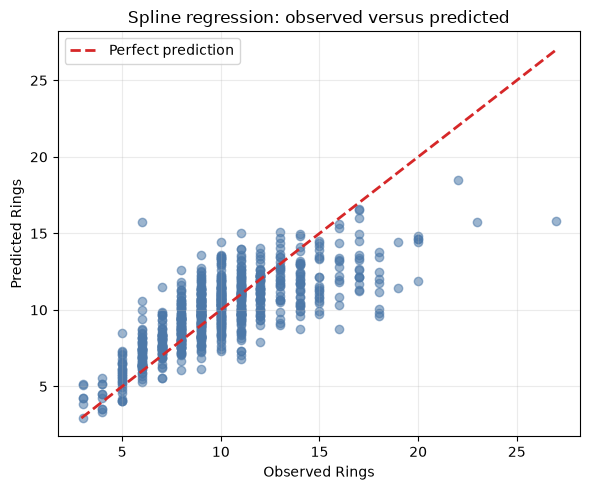

In [17]:
spline_preprocessor = ColumnTransformer([
    ("num_spline",
        Pipeline([
            ("scale", StandardScaler()),
            ("spline", SplineTransformer(n_knots=5, degree=3, include_bias=False))]), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])

spline_model = Pipeline([
    ("prep", spline_preprocessor),
    ("model", Ridge(alpha=1.0))])

spline_model.fit(X_train, y_train)
pred_spline = spline_model.predict(X_test)

regression_results.append(
    regression_metrics("Spline + Ridge", y_test, pred_spline))

display(pd.DataFrame(regression_results))
plot_observed_vs_predicted(y_test, pred_spline, "Spline regression: observed versus predicted")

## 4.3 Robust regression — Huber

Huber regression behaves approximately like squared-error regression for small residuals but reduces the influence of very large residuals.

This is useful when unusual observations would otherwise dominate the fitted line. Its loss is quadratic near zero and approximately linear for large residuals:

$$
L_\delta(r)=\begin{cases}\frac{1}{2}r^2, & |r|\leq\delta,\\ \delta(|r|-\frac{1}{2}\delta), & |r|>\delta.\end{cases}
$$

`max_iter=2000` is the maximum number of optimization iterations; it affects convergence, not the statistical form of the model.

,model,MAE,RMSE,R2
0,Linear regression,1.555982,2.115134,0.544654
1,Polynomial (degree 2),1.482316,2.046147,0.573872
2,Spline + Ridge,1.513583,2.068954,0.564320
3,Huber regression,1.522434,2.146778,0.530927


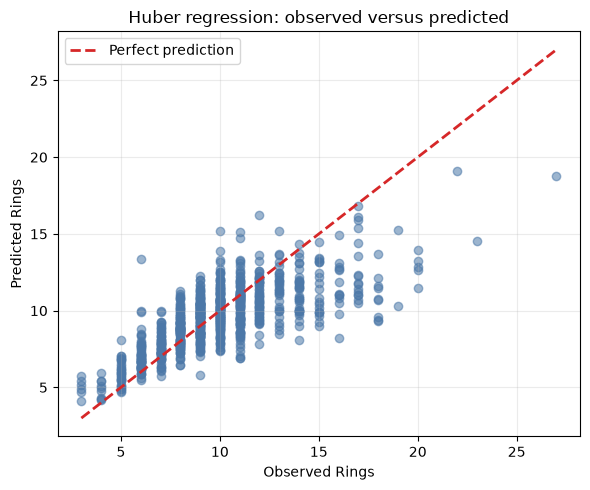

In [18]:
huber_model = Pipeline([
    ("prep", preprocessor),
    ("model", HuberRegressor(max_iter=2000))
])

huber_model.fit(X_train, y_train)
pred_huber = huber_model.predict(X_test)

regression_results.append(
    regression_metrics("Huber regression", y_test, pred_huber)
)

display(pd.DataFrame(regression_results))
plot_observed_vs_predicted(y_test, pred_huber, "Huber regression: observed versus predicted")

## 4.4 Quantile regression

Ordinary regression estimates the conditional **mean**. Quantile regression can target another part of the response distribution.

For $\tau=0.5$, we estimate the conditional median. The quantile loss is

$$
L_\tau(r)=\begin{cases}\tau r, & r\geq 0,\\ (\tau-1)r, & r<0.\end{cases}
$$

Here `quantile=0.5` is the median, while `alpha=0.01` controls L1 regularization. Changing `quantile` changes the target conditional quantile, not the data itself.

In [19]:
quantile_model = Pipeline([
    ("prep", preprocessor),
    ("model", QuantileRegressor(quantile=0.5, alpha=0.01, solver="highs"))
])

quantile_model.fit(X_train, y_train)
pred_quantile = quantile_model.predict(X_test)

regression_results.append(
    regression_metrics("Quantile regression (median)", y_test, pred_quantile)
)

display(pd.DataFrame(regression_results))


,model,MAE,RMSE,R2
0,Linear regression,1.555982,2.115134,0.544654
1,Polynomial (degree 2),1.482316,2.046147,0.573872
2,Spline + Ridge,1.513583,2.068954,0.564320
3,Huber regression,1.522434,2.146778,0.530927
4,Quantile regression (median),1.580649,2.273693,0.473826


## 4.5 PCR — Principal Component Regression

PCR:

1. preprocesses $X$;
2. finds principal components explaining variation in $X$;
3. uses selected PCs for regression.

The PCA step does **not** know the target. If $Z=PX$ denotes the PC scores, PCR fits

$$
\hat{y}=\beta_0+\beta_1Z_1+\cdots+\beta_kZ_k.
$$

`n_components=5` selects how many PCs are passed to the regression. The diagnostic below plots `Rings` against PC1, even though the PCR model uses all five selected components.

,model,MAE,RMSE,R2
0,Linear regression,1.555982,2.115134,0.544654
1,Polynomial (degree 2),1.482316,2.046147,0.573872
2,Spline + Ridge,1.513583,2.068954,0.564320
3,Huber regression,1.522434,2.146778,0.530927
4,Quantile regression (median),1.580649,2.273693,0.473826
5,PCR (5 PCs),1.759706,2.409291,0.409194


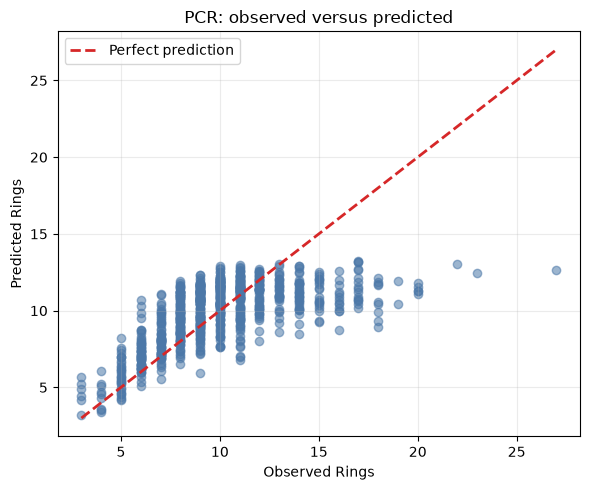

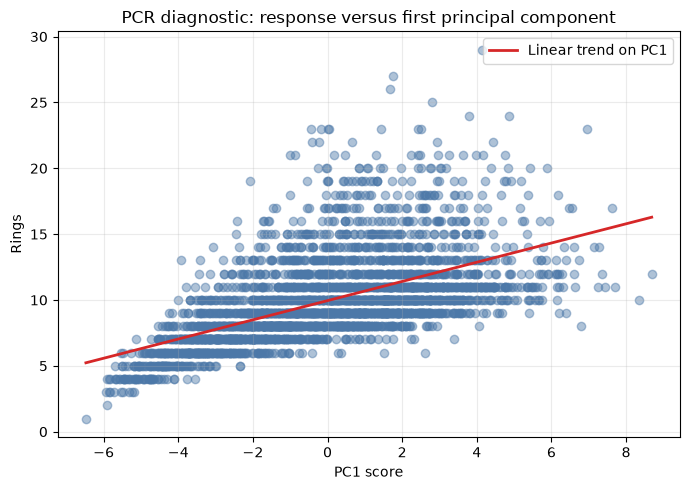

In [20]:
pcr_model = Pipeline([
    ("prep", preprocessor),
    ("pca", PCA(n_components=5)),
    ("model", LinearRegression())
])

pcr_model.fit(X_train, y_train)
pred_pcr = pcr_model.predict(X_test)

regression_results.append(
    regression_metrics("PCR (5 PCs)", y_test, pred_pcr))

display(pd.DataFrame(regression_results))
plot_observed_vs_predicted(y_test, pred_pcr, "PCR: observed versus predicted")

# Visualize the first principal component as a one-dimensional diagnostic.
X_train_pca = pcr_model.named_steps["pca"].transform(
    pcr_model.named_steps["prep"].transform(X_train)
)
pc1 = X_train_pca[:, 0]
pc1_line = np.polyfit(pc1, y_train.to_numpy(), deg=1)
pc1_grid = np.linspace(pc1.min(), pc1.max(), 100)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pc1, y_train, alpha=0.45, color="#4c78a8")
ax.plot(pc1_grid, np.polyval(pc1_line, pc1_grid), color="#d62728", linewidth=2, label="Linear trend on PC1")
ax.set_xlabel("PC1 score")
ax.set_ylabel("Rings")
ax.set_title("PCR diagnostic: response versus first principal component")
ax.grid(alpha=0.25)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## 4.6 PLSR — Partial Least Squares Regression

PLSR also creates latent components, but unlike PCR it constructs them using information about the relationship between $X$ and $Y$.

This is especially common in chemometrics, spectroscopy, metabolomics, and correlated molecular descriptor data.

PLSR chooses latent scores using both predictors and response:

$$
X \rightarrow T, \qquad Y \approx TQ^\top.
$$

`n_components=5` controls the number of supervised latent components. The diagnostic below shows `Rings` against the first PLS component.

,model,MAE,RMSE,R2
0,Linear regression,1.555982,2.115134,0.544654
1,Polynomial (degree 2),1.482316,2.046147,0.573872
2,Spline + Ridge,1.513583,2.068954,0.564320
3,Huber regression,1.522434,2.146778,0.530927
4,Quantile regression (median),1.580649,2.273693,0.473826
5,PCR (5 PCs),1.759706,2.409291,0.409194
6,PLSR (5 components),1.567733,2.130555,0.537990


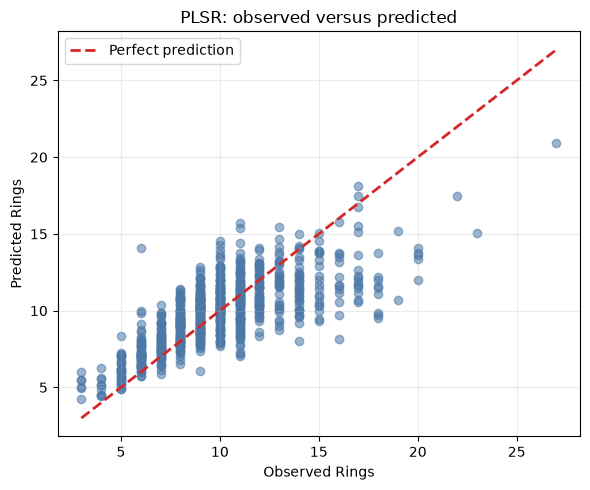

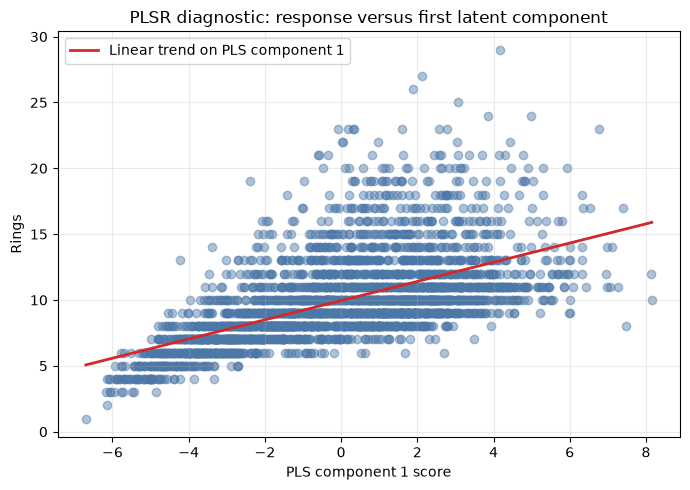

In [21]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrices if needed
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

pls = PLSRegression(n_components=5)
pls.fit(X_train_processed, y_train)

pred_pls = pls.predict(X_test_processed).ravel()

regression_results.append(
    regression_metrics("PLSR (5 components)", y_test, pred_pls)
)

display(pd.DataFrame(regression_results))
plot_observed_vs_predicted(y_test, pred_pls, "PLSR: observed versus predicted")

pls1 = pls.x_scores_[:, 0]
pls1_line = np.polyfit(pls1, y_train.to_numpy(), deg=1)
pls1_grid = np.linspace(pls1.min(), pls1.max(), 100)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pls1, y_train, alpha=0.45, color="#4c78a8")
ax.plot(pls1_grid, np.polyval(pls1_line, pls1_grid), color="#d62728", linewidth=2, label="Linear trend on PLS component 1")
ax.set_xlabel("PLS component 1 score")
ax.set_ylabel("Rings")
ax.set_title("PLSR diagnostic: response versus first latent component")
ax.grid(alpha=0.25)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## 4.7 Gaussian Process Regression

A Gaussian Process models a **distribution over functions** and can provide predictive uncertainty.

$$
f(x) \sim \mathcal{GP}(m(x), k(x,x')).
$$

`n_restarts_optimizer=0` controls how many additional kernel-parameter optimization starts are attempted. More restarts can improve the kernel fit but increase runtime.

,model,MAE,RMSE,R2
0,Linear regression,1.555982,2.115134,0.544654
1,Polynomial (degree 2),1.482316,2.046147,0.573872
2,Spline + Ridge,1.513583,2.068954,0.564320
3,Huber regression,1.522434,2.146778,0.530927
4,Quantile regression (median),1.580649,2.273693,0.473826
5,PCR (5 PCs),1.759706,2.409291,0.409194
6,PLSR (5 components),1.567733,2.130555,0.537990
7,Gaussian Process (subset),1.502064,2.058603,0.568669


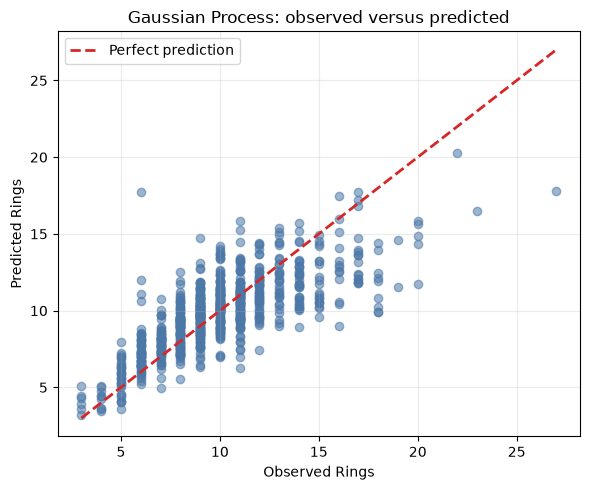

In [22]:
gp_features = ["Length", "Diameter", "Height", "Whole_weight",
               "Shucked_weight", "Viscera_weight", "Shell_weight"]

gp_train = X_train[gp_features].copy()
gp_test = X_test[gp_features].copy()

gp_scaler = StandardScaler()
gp_train_s = gp_scaler.fit_transform(gp_train)
gp_test_s = gp_scaler.transform(gp_test)


kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    random_state=RANDOM_STATE,
    n_restarts_optimizer=0
)

gp.fit(gp_train_s, y_train)

pred_gp, pred_gp_sd = gp.predict(gp_test_s, return_std=True)

regression_results.append(
    regression_metrics("Gaussian Process (subset)", y_test, pred_gp))

display(pd.DataFrame(regression_results))
plot_observed_vs_predicted(y_test, pred_gp, "Gaussian Process: observed versus predicted")

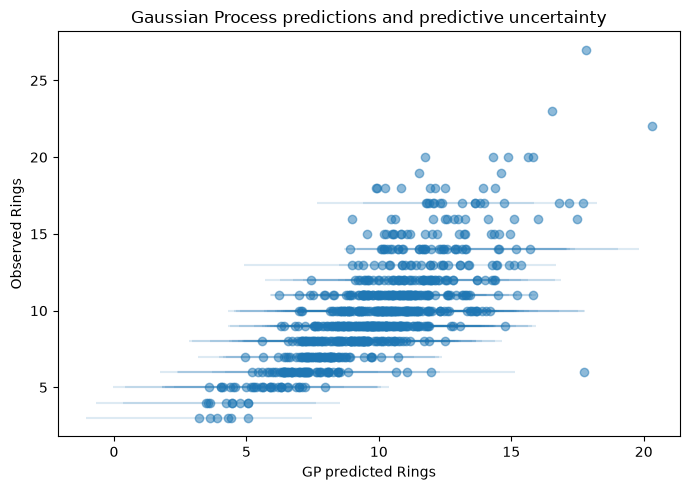

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pred_gp, y_test, alpha=0.5)
ax.errorbar(
    pred_gp[:100],
    y_test.iloc[:100],
    xerr=1.96 * pred_gp_sd[:100],
    fmt="none",
    alpha=0.15)
    
ax.set_xlabel("GP predicted Rings")
ax.set_ylabel("Observed Rings")
ax.set_title("Gaussian Process predictions and predictive uncertainty")
plt.tight_layout()
plt.show()

## 4.8 MARS — Multivariate Adaptive Regression Splines

MARS builds piecewise relationships using hinge functions such as

$$
\max(0, x-t)
$$

and can discover useful knots/interactions automatically.

`max_degree=2` limits the highest-order interaction among hinge functions. `py-earth` / `sklearn-contrib-py-earth` can be platform-dependent, so this cell is safe to skip if the package is unavailable.

In [24]:
# OPTIONAL — run if pyearth is installed.
try:
    from pyearth import Earth

    mars = Earth(max_degree=2)

    # Reuse dense, preprocessed features
    mars.fit(X_train_processed, y_train)
    pred_mars = mars.predict(X_test_processed)

    regression_results.append(
        regression_metrics("MARS", y_test, pred_mars)
    )
    plot_observed_vs_predicted(y_test, pred_mars, "MARS: observed versus predicted")
    print(mars.summary())

except Exception as e:
    print("MARS was not run:", e)
    print("Install a compatible py-earth/sklearn-contrib-py-earth build to execute this section.")

MARS was not run: No module named 'pyearth'
Install a compatible py-earth/sklearn-contrib-py-earth build to execute this section.


## 4.9 GAM — Generalized Additive Model

A GAM can be written conceptually as

$$
g(E[Y])=\beta_0+f_1(x_1)+f_2(x_2)+\dots
$$

where each predictor can have its own smooth function.

Below we use the numeric measurements only to keep the example compact. The term `s(i)` adds a smooth function for predictor `i`; `n_splines` controls the size of the basis used for that smooth.

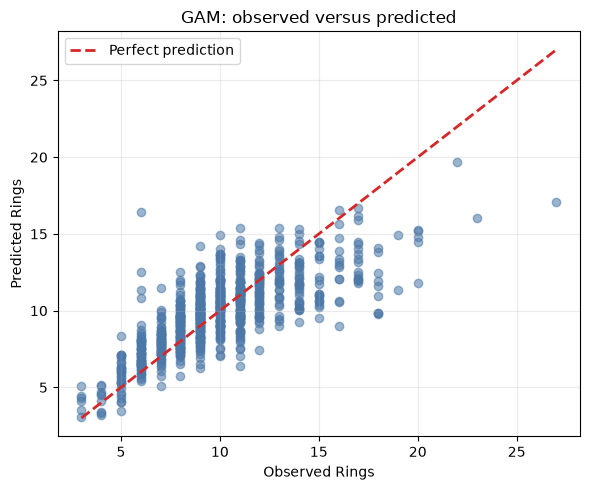

,model,MAE,RMSE,R2
0,Linear regression,1.555982,2.115134,0.544654
1,Polynomial (degree 2),1.482316,2.046147,0.573872
2,Spline + Ridge,1.513583,2.068954,0.564320
3,Huber regression,1.522434,2.146778,0.530927
4,Quantile regression (median),1.580649,2.273693,0.473826
5,PCR (5 PCs),1.759706,2.409291,0.409194
6,PLSR (5 components),1.567733,2.130555,0.537990
7,Gaussian Process (subset),1.502064,2.058603,0.568669
8,GAM,1.523044,2.076065,0.561320


In [25]:
try:
    from pygam import LinearGAM, s

    X_gam_train = X_train[gp_features].to_numpy()
    X_gam_test = X_test[gp_features].to_numpy()

    # One smooth term per numeric predictor
    gam = LinearGAM(
        s(0, n_splines=10) + s(1, n_splines=10) + s(2, n_splines=10) +
        s(3, n_splines=10) + s(4, n_splines=10) + s(5, n_splines=10) + s(6, n_splines=10)
    ).fit(X_gam_train, y_train)

    pred_gam = gam.predict(X_gam_test)

    regression_results.append(
        regression_metrics("GAM", y_test, pred_gam)
    )
    plot_observed_vs_predicted(y_test, pred_gam, "GAM: observed versus predicted")

except Exception as e:
    print("GAM was not run:", e)
    print("Install pygam to execute this section.")

display(pd.DataFrame(regression_results))

## 4.10 Symbolic regression

Symbolic regression searches not only coefficient values but also the **mathematical form of the equation**.

That makes it particularly interesting when we want an explicit equation rather than only predictions.

We will use a small set of biologically interpretable continuous measurements and PySR. 

The main tuning parameters are `niterations` (number of evolutionary search iterations), `populations` and `population_size` (search breadth), and `maxsize` (maximum expression complexity). Increasing them can improve the search but increases runtime.

> A readable equation is **not automatically a biological mechanism**.

In [26]:
symbolic_features = [
    "Length",
    "Diameter",
    "Whole_weight",
    "Shucked_weight",
    "Shell_weight"]

X_sym_train = X_train[symbolic_features].to_numpy()
X_sym_test = X_test[symbolic_features].to_numpy()

sym_scaler = StandardScaler()
X_sym_train_s = sym_scaler.fit_transform(X_sym_train)
X_sym_test_s = sym_scaler.transform(X_sym_test)

print("Symbolic-regression predictors:", symbolic_features)

Symbolic-regression predictors: ['Length', 'Diameter', 'Whole_weight', 'Shucked_weight', 'Shell_weight']


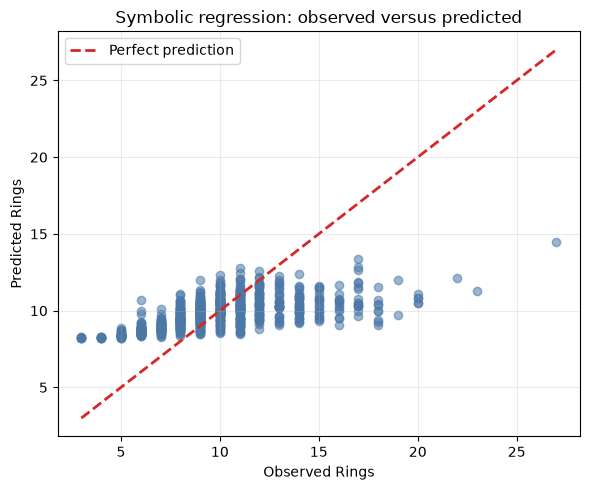

Selected symbolic equation:


Shell_weight + 9.882008

In [27]:
try:
    from pysr import PySRRegressor

    symbolic_model = PySRRegressor(
        niterations=10,
        populations=5,
        population_size=20,
        binary_operators=["+", "-", "*", "/"],
        unary_operators=["square", "cube", "cos", "exp", "sin"],
        model_selection="best",
        maxsize=20,
        random_state=RANDOM_STATE,
        verbosity=0)

    symbolic_model.fit(
        X_sym_train_s,
        y_train,
        variable_names=symbolic_features
    )

    pred_symbolic = symbolic_model.predict(X_sym_test_s)

    regression_results.append(
        regression_metrics("Symbolic regression", y_test, pred_symbolic)
    )
    plot_observed_vs_predicted(y_test, pred_symbolic, "Symbolic regression: observed versus predicted")

    print("Selected symbolic equation:")
    display(symbolic_model.sympy())

except Exception as e:
    print("Symbolic regression was not run:", e)
    print("Install/configure PySR, then rerun this cell.")

## 4.11 Count regression — Poisson / Negative Binomial

`Rings` is an integer count, so count regression is worth discussing. However, whether Poisson is appropriate depends on its distributional assumptions.

A central diagnostic is the relationship between mean and variance:

- Poisson: variance is approximately tied to the mean;
- Negative Binomial: allows **overdispersion**.

This connects directly to RNA-seq: **DESeq2 models read counts using a Negative Binomial GLM**.

For a Poisson GLM,

$$
Y_i \sim \operatorname{Poisson}(\lambda_i), \qquad \log(\lambda_i)=\mathbf{x}_i^\top\beta.
$$

The Negative Binomial model allows extra-Poisson variation; one common parameterization is $\operatorname{Var}(Y_i)=\mu_i+\alpha\mu_i^2$. The fitted `alpha` below is the estimated overdispersion parameter.

In [28]:
rings_mean = df["Rings"].mean()
rings_var = df["Rings"].var()

print(f"Mean Rings:     {rings_mean:.3f}")
print(f"Variance Rings: {rings_var:.3f}")
print(f"Variance / mean: {rings_var / rings_mean:.3f}")

Mean Rings:     9.934
Variance Rings: 10.395
Variance / mean: 1.046


C:\Users\user\Desktop\kse\practicals\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


,model,AIC,Test RMSE
0,Poisson GLM,15448.32663,2.305823
1,Negative Binomial,15450.32871,2.305710


Estimated Negative Binomial dispersion (alpha): 4.9122923092194475e-09


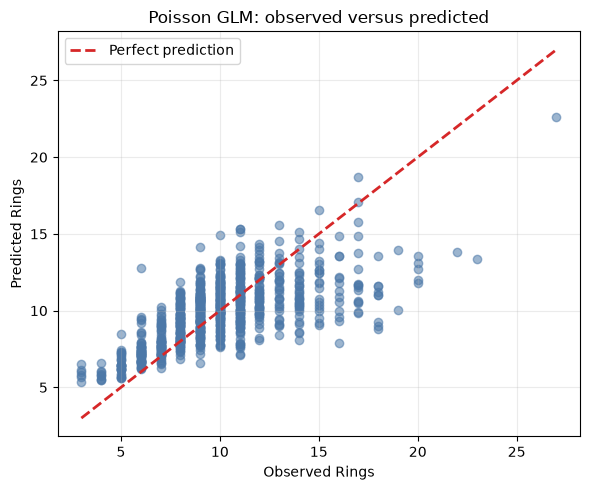

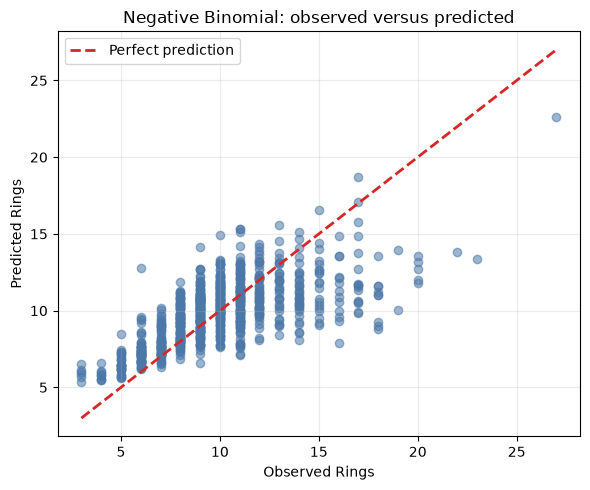

In [29]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

count_formula = "Rings ~ Length + Diameter + Whole_weight + Shell_weight + C(Sex)"
count_train = df.loc[X_train.index].copy()
count_test = df.loc[X_test.index].copy()

poisson_fit = smf.glm(
    count_formula,
    data=count_train,
    family=sm.families.Poisson()).fit()

# The discrete Negative Binomial model estimates an overdispersion parameter.
negative_binomial_fit = smf.negativebinomial(
    count_formula,
    data=count_train).fit(disp=False)

pred_poisson = poisson_fit.predict(count_test)
pred_negative_binomial = negative_binomial_fit.predict(count_test)
regression_results.extend([
    regression_metrics("Poisson GLM", count_test["Rings"], pred_poisson),
    regression_metrics("Negative Binomial", count_test["Rings"], pred_negative_binomial),
])

count_model_summary = pd.DataFrame({
    "model": ["Poisson GLM", "Negative Binomial"],
    "AIC": [poisson_fit.aic, negative_binomial_fit.aic],
    "Test RMSE": [
        np.sqrt(mean_squared_error(count_test["Rings"], pred_poisson)),
        np.sqrt(mean_squared_error(count_test["Rings"], pred_negative_binomial)),
    ],
})
display(count_model_summary)
print("Estimated Negative Binomial dispersion (alpha):", negative_binomial_fit.params.get("alpha", np.nan))
plot_observed_vs_predicted(count_test["Rings"], pred_poisson, "Poisson GLM: observed versus predicted")
plot_observed_vs_predicted(count_test["Rings"], pred_negative_binomial, "Negative Binomial: observed versus predicted")

# 5. Mixed-effects regression — why grouping matters

Mixed-effects models are particularly important in biosciences because observations are often **not independent**
- repeated measurements from the same patient;
- multiple tissue samples from one donor;
- several wells from one biological sample;
- repeated animals within litters/cages;
- technical replicates.

The original Abalone dataset has **one row per individual** and no repeated-individual identifier so we will create a **pseudoreplication experiment**.

## 5.1 Create artificial technical pseudoreplicates

For each original abalone we create three measurements with very small measurement noise.

All three rows share the same `Individual_ID`.

This dataset is **synthetic and only demonstrates the statistical structure**:

$$
y_{ij}=\beta_0+\beta_1x_{ij}+b_i+\epsilon_{ij}
$$

where $b_i$ represents an individual-specific random intercept.


In [30]:
rng = np.random.default_rng(RANDOM_STATE)

base = df[
    ["Length", "Diameter", "Whole_weight", "Shell_weight", "Rings"]
].copy().reset_index(drop=True)

base["Individual_ID"] = [f"abalone_{i:04d}" for i in range(len(base))]

pseudo_parts = []

for replicate in range(3):
    tmp = base.copy()
    tmp["Technical_replicate"] = replicate + 1

    for col in ["Length", "Diameter", "Whole_weight", "Shell_weight"]:
        sd = base[col].std() * 0.01
        tmp[col] = tmp[col] + rng.normal(0, sd, size=len(tmp))

    tmp["Rings_measured"] = (
        tmp["Rings"] + rng.normal(0, 0.35, size=len(tmp))
    )

    pseudo_parts.append(tmp)

pseudo = pd.concat(pseudo_parts, ignore_index=True)

display(pseudo.head(9))
print("Rows:", len(pseudo))
print("Biological individuals:", pseudo["Individual_ID"].nunique())

,Length,Diameter,Whole_weight,Shell_weight,Rings,Individual_ID,Technical_replicate,Rings_measured
0,0.454318,0.367545,0.509752,0.148076,15,abalone_0000,1,15.003527
1,0.348781,0.265064,0.227140,0.068592,7,abalone_0001,1,6.870732
2,0.529968,0.420311,0.677141,0.207583,9,abalone_0002,1,8.888474
3,0.440898,0.364608,0.523394,0.152923,10,abalone_0003,1,9.520864
4,0.327977,0.253537,0.210432,0.053878,7,abalone_0004,1,6.799911
5,0.424302,0.299881,0.357583,0.119706,8,abalone_0005,1,7.928380
6,0.531928,0.414603,0.778171,0.331062,20,abalone_0006,1,19.850320
7,0.545999,0.425228,0.761758,0.260998,16,abalone_0007,1,16.462731
8,0.473755,0.370811,0.512216,0.167653,9,abalone_0008,1,8.931317


Rows: 12531
Biological individuals: 4177


### What goes wrong with ordinary regression?

If we simply treat all pseudoreplicates as independent rows, the model ignores within-individual dependence.

A mixed model explicitly represents this grouping.

In [31]:
# Ordinary regression that incorrectly treats all pseudoreplicates as independent
ols_pseudo = smf.ols("Rings_measured ~ Length + Diameter + Whole_weight + Shell_weight", data=pseudo).fit()

print(ols_pseudo.summary().tables[1])

                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        4.0525      0.165     24.577      0.000       3.729       4.376
Length          -4.6272      1.134     -4.079      0.000      -6.851      -2.403
Diameter        16.2679      1.389     11.712      0.000      13.545      18.990
Whole_weight    -5.8702      0.174    -33.746      0.000      -6.211      -5.529
Shell_weight    27.3867      0.537     50.993      0.000      26.334      28.439


In [32]:
# Random-intercept mixed-effects model
mixed_model = smf.mixedlm("Rings_measured ~ Length + Diameter + Whole_weight + Shell_weight",
    data=pseudo,
    groups=pseudo["Individual_ID"])

mixed_fit = mixed_model.fit(method="lbfgs")

print(mixed_fit.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Rings_measured
No. Observations: 12531   Method:             REML          
No. Groups:       4177    Scale:              0.1265        
Min. group size:  3       Log-Likelihood:     -15095.0117   
Max. group size:  3       Converged:          Yes           
Mean group size:  3.0                                       
------------------------------------------------------------
                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         4.236    0.274  15.435 0.000  3.698  4.774
Length           -2.822    1.520  -1.856 0.063 -5.801  0.158
Diameter         13.246    1.860   7.122 0.000  9.601 16.892
Whole_weight     -4.598    0.275 -16.736 0.000 -5.136 -4.059
Shell_weight     23.401    0.855  27.364 0.000 21.725 25.077
Group Var         5.722    0.438                            



## 8. Compare the fitted regression models

In [33]:
regression_table = (
    pd.DataFrame(regression_results)
    .sort_values("RMSE")
    .reset_index(drop=True))

display(regression_table)

,model,MAE,RMSE,R2
0,Polynomial (degree 2),1.482316,2.046147,0.573872
1,Gaussian Process (subset),1.502064,2.058603,0.568669
2,Spline + Ridge,1.513583,2.068954,0.564320
3,GAM,1.523044,2.076065,0.561320
4,Linear regression,1.555982,2.115134,0.544654
5,PLSR (5 components),1.567733,2.130555,0.537990
6,Huber regression,1.522434,2.146778,0.530927
7,Quantile regression (median),1.580649,2.273693,0.473826
8,Negative Binomial,1.706512,2.305710,0.458903
9,Poisson GLM,1.706582,2.305823,0.458850


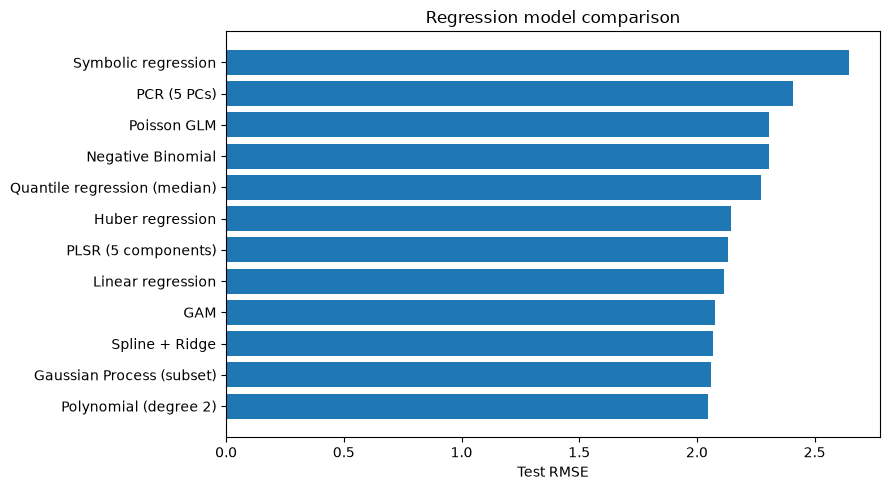

In [34]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = regression_table.sort_values("RMSE", ascending=True)
ax.barh(plot_df["model"], plot_df["RMSE"])
ax.set_xlabel("Test RMSE")
ax.set_title("Regression model comparison")
plt.tight_layout()
plt.show()

# Part III - Classification

We now ask a different question using the same predictors:

> Can physical measurements classify an abalone into our teaching age categories?

Logistic regression is fitted by minimizing log loss:

$$
\mathcal{L}_{\mathrm{log}}=-\sum_i\sum_k y_{ik}\log p_{ik}.
$$

Recall and F1 are not differentiable training losses for `LogisticRegression`. We can still make the model recall- or F1-oriented by selecting its hyperparameters with `scoring="recall_macro"` or `scoring="f1_macro"`, and by choosing a classification threshold after fitting.

In [35]:
X_cls = df.drop(columns=["Rings", "Age_class"])
y_cls = df["Age_class"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_cls)

classification_model = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=3000))
])

classification_model.fit(Xc_train, yc_train)

cls_pred = classification_model.predict(Xc_test)
cls_proba = classification_model.predict_proba(Xc_test)

print(classification_report(yc_test, cls_pred))
print("Balanced accuracy:", balanced_accuracy_score(yc_test, cls_pred))
print("Macro F1:", f1_score(yc_test, cls_pred, average="macro"))

              precision    recall  f1-score   support

      middle       0.51      0.51      0.51       265
         old       0.73      0.67      0.70       290
       young       0.71      0.77      0.74       281

    accuracy                           0.65       836
   macro avg       0.65      0.65      0.65       836
weighted avg       0.65      0.65      0.65       836

Balanced accuracy: 0.650285446144181
Macro F1: 0.6495147732313932


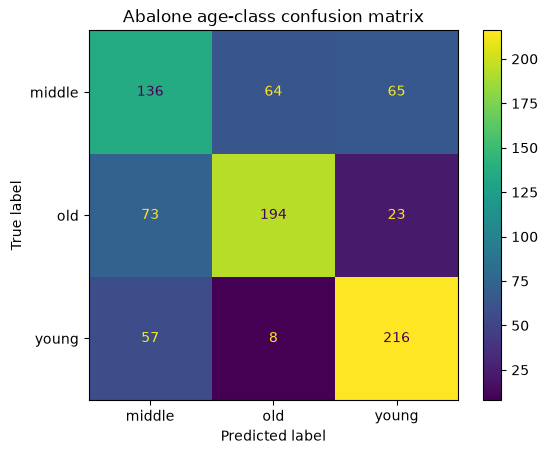

In [36]:
ConfusionMatrixDisplay.from_predictions(
    yc_test,
    cls_pred,
    cmap=None)
    
plt.title("Abalone age-class confusion matrix")
plt.show()

## Choosing recall or F1 as the model-selection objective

The logistic model still learns probabilities with log loss. Recall and F1 are used here as **selection metrics**: they can choose the regularization strength `C` in cross-validation, or determine a probability threshold for calling one class positive. This distinction is important because recall and F1 are evaluation objectives rather than ordinary differentiable losses for this estimator.

In [37]:
# 1. Tune the logistic model using different selection metrics.
metric_search_results = []
for metric_name in ["recall_macro", "f1_macro"]:
    metric_search = GridSearchCV(
        classification_model,
        param_grid={"model__C": [0.1, 1.0, 10.0]},
        scoring=metric_name,
        cv=5,
        n_jobs=-1)
        
    metric_search.fit(Xc_train, yc_train)
    metric_pred = metric_search.predict(Xc_test)
    metric_search_results.append({
        "selection_metric": metric_name,
        "best_C": metric_search.best_params_["model__C"],
        "test_balanced_accuracy": balanced_accuracy_score(yc_test, metric_pred),
        "test_macro_recall": recall_score(yc_test, metric_pred, average="macro", zero_division=0),
        "test_macro_F1": f1_score(yc_test, metric_pred, average="macro"),
    })
display(pd.DataFrame(metric_search_results))

# 2. Tune the threshold for detecting the 'old' class.
class_names = classification_model.named_steps["model"].classes_
positive_class = "old"
positive_index = list(class_names).index(positive_class)

def predict_old_with_threshold(probabilities, threshold):
    positive_mask = probabilities[:, positive_index] >= threshold
    alternatives = probabilities.copy()
    alternatives[:, positive_index] = -np.inf
    fallback = class_names[np.argmax(alternatives, axis=1)]
    return np.where(positive_mask, positive_class, fallback)

threshold_results = []
for threshold in [0.30, 0.50, 0.70]:
    threshold_pred = predict_old_with_threshold(cls_proba, threshold)
    threshold_results.append({
        "old_threshold": threshold,
        "old_recall": recall_score(yc_test, threshold_pred, labels=[positive_class], average="macro", zero_division=0),
        "macro_recall": recall_score(yc_test, threshold_pred, average="macro", zero_division=0),
        "macro_F1": f1_score(yc_test, threshold_pred, average="macro"),
    })
display(pd.DataFrame(threshold_results))

,selection_metric,best_C,test_balanced_accuracy,test_macro_recall,test_macro_F1
0,recall_macro,10.0,0.645471,0.645471,0.644803
1,f1_macro,10.0,0.645471,0.645471,0.644803


,old_threshold,old_recall,macro_recall,macro_F1
0,0.3,0.824138,0.616475,0.591794
1,0.5,0.627586,0.644040,0.644557
2,0.7,0.362069,0.602075,0.591994


# Part IV - QSAR Bioconcentration Classes

The QSAR Bioconcentration Classes dataset contains manually curated fish bioconcentration information for **779 compounds** with **14 molecular features**.

The challenge should be treated as an independent evaluation task:

- perform EDA
- identify the regression and classification targets
- create an internal validation strategy using only the labelled 80%
- choose preprocessing
- choose models
- evaluate locally
- train final models
- predict the hidden 20%
- submit predictions


In [38]:
df = pd.read_csv("Grisoni_et_al_2016_EnvInt88.csv")
df

,CAS,SMILES,Set,nHM,piPC09,PCD,X2Av,MLOGP,ON1V,N-072,B02[C-N],F04[C-O],Class,logBCF
0,100-02-7,O=[N+](c1ccc(cc1)O)[O-],Train,0,0.000,1.49,0.14,1.35,0.72,0,1,5,1,0.74
1,100-17-4,O=[N+](c1ccc(cc1)OC)[O-],Train,0,0.000,1.47,0.14,1.70,0.88,0,1,5,1,0.93
2,100-18-5,c1cc(ccc1C(C)C)C(C)C,Train,0,0.000,1.20,0.25,4.14,2.06,0,0,0,3,3.24
3,100-25-4,O=[N+]([O-])c1ccc(cc1)[N+](=O)[O-],Train,0,0.000,1.69,0.13,1.89,0.79,0,1,8,3,-0.40
4,100-40-3,C=CC1CCC=CC1,Train,0,0.000,0.52,0.25,2.65,1.31,0,0,0,1,2.24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
774,99-30-9,O=[N+]([O-])c1cc(c(N)c(c1)Cl)Cl,Train,2,0.000,1.48,0.17,2.57,0.73,0,1,4,1,1.88
775,99387-89-0,FC(F)(F)c2cc(ccc2(N=C(n1cncc1)COCCC))Cl,Test,1,6.564,2.37,0.16,3.77,2.28,0,1,3,2,2.59
776,99-65-0,O=[N+]([O-])c1cccc(c1)[N+](=O)[O-],Train,0,0.000,1.71,0.13,1.89,0.79,0,1,8,1,0.77
777,99-71-8,CC(c1ccc(cc1)O)CC,Test,0,0.000,1.19,0.21,2.81,1.69,0,0,1,3,1.35


## 11. Student challenge

You receive:

### `QSAR_challenge_train_80pct.csv`

Contains:

- `sample_id`
- molecular predictors
- `regression_target`
- `classification_target`

### `QSAR_challenge_test_20pct_NO_TARGETS.csv`

Contains:

- `sample_id`
- molecular predictors

Your task is to train **two models**:

1. a regression model;
2. a classification model.

You may use methods covered so far in the course.

### Important

Use cross-validation or an internal train/validation split **inside the 80% labelled dataset** for model selection.

In [ ]:
train = pd.read_csv("QSAR_challenge_train_80pct.csv")
test = pd.read_csv("QSAR_challenge_test_20pct_NO_TARGETS.csv")

feature_cols = [
    c for c in test.columns
    if c != "sample_id"
]

X_train_challenge = train[feature_cols]
X_hidden_challenge = test[feature_cols]

y_reg_challenge = train["regression_target"]
y_cls_challenge = train["classification_target"]

print(X_train_challenge.shape, X_hidden_challenge.shape)
display(train.head())

(623, 9) (156, 9)


,sample_id,nHM,piPC09,PCD,X2Av,MLOGP,ON1V,N-072,B02[C-N],F04[C-O],regression_target,classification_target
0,2234-13-1,8,7.157,2.41,0.21,6.55,0.97,0,0,0,2.58,3
1,108-42-9,1,0.000,1.23,0.20,2.13,0.68,0,1,0,0.33,3
2,106-43-4,1,0.000,1.23,0.22,3.21,0.84,0,0,0,1.80,1
3,108-87-2,0,0.000,0.00,0.34,3.48,1.67,0,0,0,2.32,1
4,101-81-5,0,5.614,2.21,0.19,4.15,1.47,0,0,0,2.97,1


## 12. Required submission

Submit one CSV containing:

- `sample_id`
- `regression_prediction`
- `classification_prediction`

If your classification method provides probabilities, also include probability columns. For multiclass classification, use one probability column per class.

Example:

`probability_class_1`, `probability_class_2`, ...

In [41]:
# TEMPLATE — replace placeholders with your fitted models.

submission = pd.DataFrame({
    "sample_id": test["sample_id"]
})

# submission["regression_prediction"] = regression_model.predict(X_hidden_challenge)
# submission["classification_prediction"] = classification_model.predict(X_hidden_challenge)


display(submission.head())

# submission.to_csv("submission_your_name.csv", index=False)

,sample_id
0,78-79-5
1,16606-02-3
2,111-44-4
3,107-05-1
4,555-03-3


# Final questions

1. Which regression method performed best on Abalone?
2. Did the most flexible model necessarily generalize best?
3. How did robust and quantile regression differ conceptually from OLS?
4. Why are PCR and PLSR not equivalent?
5. Why did we fit the Gaussian Process only on a subset?
6. What does symbolic regression provide that ordinary regression does not?
7. Why was the mixed-effects example based on synthetic pseudoreplicates?
8. Why would randomly splitting those pseudoreplicates create leakage?
9. Why did we *not* fit survival regression to Abalone?
10. For the QSAR challenge, how closely did your internal validation performance predict hidden-set performance?
11. Why are recall and F1 better treated as selection metrics or threshold criteria than as the direct loss for this logistic-regression estimator?